<a href="https://colab.research.google.com/github/Saikotgire24/AI-Models/blob/main/CNN_Image_Classification_Cat_Vs_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# ============================================================
# CNN ASSIGNMENT - CATS VS DOGS
# Custom CNN vs Transfer Learning
# Framework: TensorFlow / Keras
# ============================================================

# ==============================
# STUDENT INFORMATION
# ==============================
BITS_ID = "2025AE05468"   # CHANGE THIS
NAME = "SAINATH KOTGIRE"        # CHANGE THIS
EMAIL = "2025ae05468@wilp.bits-pilani.ac.in"  # CHANGE THIS

print("BITS ID:", BITS_ID)
print("Name:", NAME)
print("Email:", EMAIL)

BITS ID: 2025AE05468
Name: SAINATH KOTGIRE
Email: 2025ae05468@wilp.bits-pilani.ac.in


In [1]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.FH58V4_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [2]:
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:20%]', 'train[20%:25%]'],  # small subset
    as_supervised=True,
    with_info=True
)

In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [4]:
# ==============================
# INSTALL / IMPORTS
# ==============================
!pip install -q tensorflow-datasets

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU: []


In [5]:
# ==============================
# CONFIG
# ==============================
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS_CUSTOM = 8
EPOCHS_TRANSFER = 5
NUM_CLASSES = 2

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
# ==============================
# PREPROCESSING
# ==============================
def preprocess_custom(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def preprocess_transfer(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_custom = (
    ds_train
    .map(preprocess_custom, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_custom = (
    ds_test
    .map(preprocess_custom, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

train_transfer = (
    ds_train
    .map(preprocess_transfer, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_transfer = (
    ds_test
    .map(preprocess_transfer, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [7]:
# ==============================
# CUSTOM CNN MODEL
# IMPORTANT: NO FLATTEN()
# Uses GlobalAveragePooling2D
# ==============================

custom_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

custom_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,506 (365.26 KB)

 Trainable params: 93,506 (365.26 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# ==============================
# TRAIN CUSTOM CNN
# ==============================

start_time = time.time()

custom_history = custom_cnn.fit(
    train_custom,
    validation_data=test_custom,
    epochs=EPOCHS_CUSTOM,
    verbose=1
)

custom_training_time = time.time() - start_time

custom_initial_loss = custom_history.history["loss"][0]
custom_final_loss = custom_history.history["loss"][-1]

custom_loss_reduction = (
    (custom_initial_loss - custom_final_loss) / custom_initial_loss
) * 100

print("\n📉 CUSTOM CNN LOSS REDUCTION")
print(f"Initial Loss: {custom_initial_loss:.6f}")
print(f"Final Loss: {custom_final_loss:.6f}")
print(f"Reduction %: {custom_loss_reduction:.2f}%")
print(f"Training Time: {custom_training_time:.2f} seconds")

Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5393 - loss: 0.6894 - val_accuracy: 0.5893 - val_loss: 0.6693
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.5935 - loss: 0.6709 - val_accuracy: 0.6237 - val_loss: 0.6541
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.5989 - loss: 0.6562 - val_accuracy: 0.6332 - val_loss: 0.6324
Epoch 4/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.6208 - loss: 0.6467 - val_accuracy: 0.6521 - val_loss: 0.6169
Epoch 5/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.6427 - loss: 0.6364 - val_accuracy: 0.6624 - val_loss: 0.6031
Epoch 6/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.6479 - loss: 0.6268 - val_accuracy: 0.6503 - val_loss: 0.6023
Epoch 7/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.6539 - loss: 0.6167 - val_accuracy: 0.6718 - val_loss: 0.5820
Epoch 8/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.6741 - loss: 0.6026 - val_accuracy: 0.

In [40]:
# ==============================
# TRANSFER LEARNING MODEL - VGG16
# IMPORTANT: Base frozen + GAP
# ==============================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

frozen_layers = sum([not layer.trainable for layer in base_model.layers])
trainable_layers = sum([layer.trainable for layer in transfer_model.layers])

print("\n📌 TRANSFER MODEL ARCHITECTURE DETAILS")
print("Base Model: VGG16")
print("Frozen layers in base model:", frozen_layers)
print("Trainable layers in full model:", trainable_layers)
print("Total parameters:", transfer_model.count_params())
print("Trainable parameters:", np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights]))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,714 (56.14 MB)

 Trainable params: 1,026 (4.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


📌 TRANSFER MODEL ARCHITECTURE DETAILS
Base Model: VGG16
Frozen layers in base model: 19
Trainable layers in full model: 2
Total parameters: 14715714
Trainable parameters: 1026


In [41]:
# ==============================
# TRAIN TRANSFER MODEL
# ==============================

start_time = time.time()

transfer_history = transfer_model.fit(
    train_transfer,
    validation_data=test_transfer,
    epochs=EPOCHS_TRANSFER,
    verbose=1
)

transfer_training_time = time.time() - start_time

transfer_initial_loss = transfer_history.history["loss"][0]
transfer_final_loss = transfer_history.history["loss"][-1]

transfer_loss_reduction = (
    (transfer_initial_loss - transfer_final_loss) / transfer_initial_loss
) * 100

print("\n📉 TRANSFER LEARNING LOSS REDUCTION")
print(f"Initial Loss: {transfer_initial_loss:.6f}")
print(f"Final Loss: {transfer_final_loss:.6f}")
print(f"Reduction %: {transfer_loss_reduction:.2f}%")
print(f"Training Time: {transfer_training_time:.2f} seconds")

Epoch 1/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 1144s 8s/step - accuracy: 0.8562 - loss: 1.2705 - val_accuracy: 0.9149 - val_loss: 0.5370
Epoch 2/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 1145s 8s/step - accuracy: 0.9319 - loss: 0.4817 - val_accuracy: 0.9313 - val_loss: 0.4088
Epoch 3/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 1157s 8s/step - accuracy: 0.9445 - loss: 0.3361 - val_accuracy: 0.9338 - val_loss: 0.3538
Epoch 4/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 1192s 8s/step - accuracy: 0.9516 - loss: 0.2517 - val_accuracy: 0.9433 - val_loss: 0.3236
Epoch 5/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 1163s 8s/step - accuracy: 0.9613 - loss: 0.1925 - val_accuracy: 0.9450 - val_loss: 0.3138

📉 TRANSFER LEARNING LOSS REDUCTION
Initial Loss: 1.270468
Final Loss: 0.192534
Reduction %: 84.85%
Training Time: 5800.61 seconds


In [42]:
# ==============================
# METRICS FUNCTION
# ==============================

def get_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)

        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)


def calculate_classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="macro")),
        "recall": float(recall_score(y_true, y_pred, average="macro")),
        "f1_score": float(f1_score(y_true, y_pred, average="macro"))
    }

In [43]:
# ==============================
# CUSTOM CNN METRICS
# ==============================

custom_y_true, custom_y_pred = get_predictions(custom_cnn, test_custom)
custom_metrics = calculate_classification_metrics(custom_y_true, custom_y_pred)

print("\n📊 CUSTOM CNN METRICS")
for k, v in custom_metrics.items():
    print(f"{k}: {v:.6f}")


📊 CUSTOM CNN METRICS
accuracy: 0.677835
precision: 0.678268
recall: 0.677119
f1_score: 0.677005


In [44]:
# ==============================
# TRANSFER LEARNING METRICS
# ==============================

transfer_y_true, transfer_y_pred = get_predictions(transfer_model, test_transfer)
transfer_metrics = calculate_classification_metrics(transfer_y_true, transfer_y_pred)

print("\n📊 TRANSFER LEARNING METRICS")
for k, v in transfer_metrics.items():
    print(f"{k}: {v:.6f}")


📊 TRANSFER LEARNING METRICS
accuracy: 0.945017
precision: 0.945195
recall: 0.945290
f1_score: 0.945017


In [45]:
# ==============================
# COMPARISON TABLE
# ==============================

comparison_df = pd.DataFrame({
    "Custom CNN": custom_metrics,
    "Transfer Learning": transfer_metrics
})

print("\n📊 MODEL COMPARISON")
print(comparison_df)


📊 MODEL COMPARISON
           Custom CNN  Transfer Learning
accuracy     0.677835           0.945017
precision    0.678268           0.945195
recall       0.677119           0.945290
f1_score     0.677005           0.945017


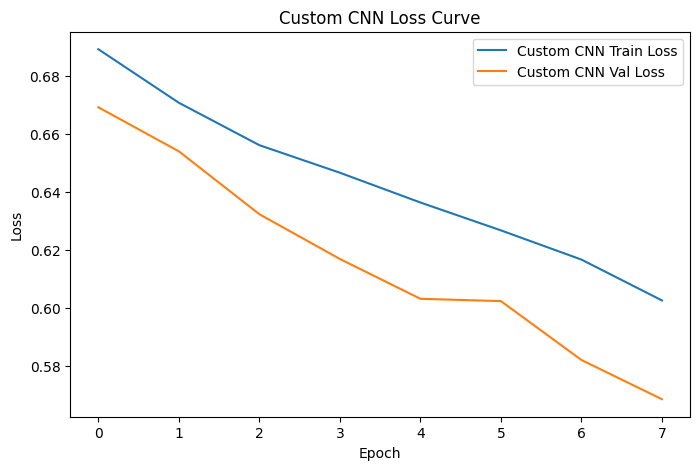

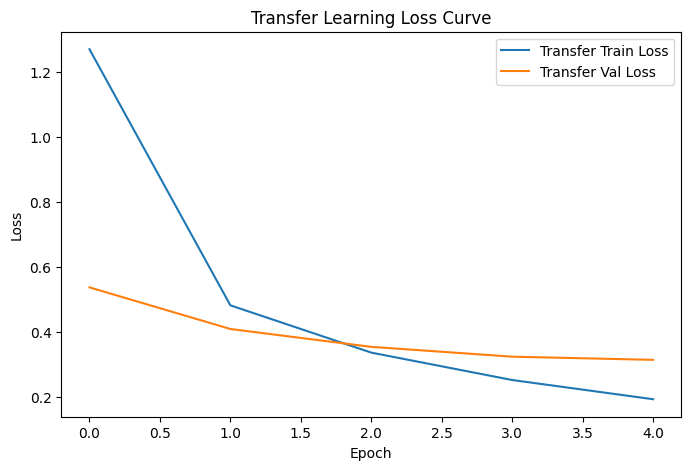

In [46]:
# ==============================
# TRAINING CURVES
# ==============================

plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["loss"], label="Custom CNN Train Loss")
plt.plot(custom_history.history["val_loss"], label="Custom CNN Val Loss")
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(transfer_history.history["loss"], label="Transfer Train Loss")
plt.plot(transfer_history.history["val_loss"], label="Transfer Val Loss")
plt.title("Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

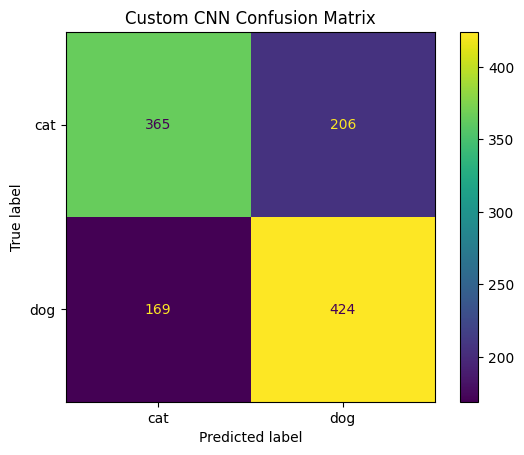

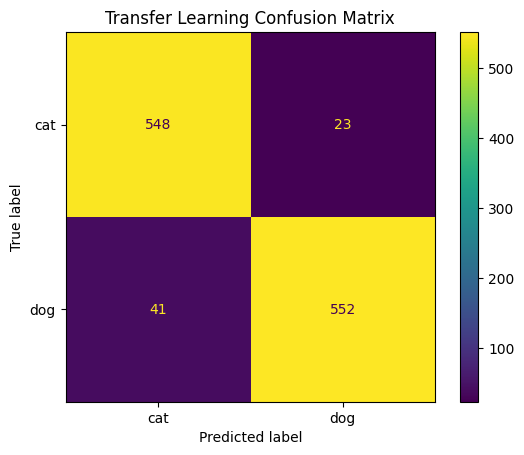

In [47]:
# ==============================
# CONFUSION MATRICES
# ==============================

class_names = ds_info.features["label"].names

cm_custom = confusion_matrix(custom_y_true, custom_y_pred)
disp_custom = ConfusionMatrixDisplay(
    confusion_matrix=cm_custom,
    display_labels=class_names
)
disp_custom.plot()
plt.title("Custom CNN Confusion Matrix")
plt.show()

cm_transfer = confusion_matrix(transfer_y_true, transfer_y_pred)
disp_transfer = ConfusionMatrixDisplay(
    confusion_matrix=cm_transfer,
    display_labels=class_names
)
disp_transfer.plot()
plt.title("Transfer Learning Confusion Matrix")
plt.show()

In [48]:
# ==============================
# PRIMARY METRIC JUSTIFICATION
# ==============================

primary_metric = "accuracy"

print("""
PRIMARY METRIC JUSTIFICATION:
Accuracy is selected as the primary metric because Cats vs Dogs is a balanced binary classification dataset.
Since both classes are equally important and there is no special penalty for false positives or false negatives,
accuracy provides a clear overall measure of classification performance.
""")


PRIMARY METRIC JUSTIFICATION:
Accuracy is selected as the primary metric because Cats vs Dogs is a balanced binary classification dataset.
Since both classes are equally important and there is no special penalty for false positives or false negatives,
accuracy provides a clear overall measure of classification performance.



In [49]:
# ==============================
# ANALYSIS PARAGRAPH
# ==============================

analysis = f"""
The transfer learning model using VGG16 performed better than the custom CNN based on the evaluation metrics.
The custom CNN was trained from scratch and had to learn low-level visual features such as edges, textures,
and shapes directly from the Cats vs Dogs dataset. In contrast, VGG16 was pre-trained on ImageNet and already
contained useful visual feature representations, allowing it to achieve stronger performance with fewer epochs.

Global Average Pooling helped reduce overfitting by replacing large Flatten-based dense layers with a compact
feature aggregation mechanism. This reduced the number of trainable parameters and encouraged the model to learn
spatially meaningful features. The custom CNN was computationally lighter, while VGG16 had many more total
parameters but fewer trainable parameters because the base layers were frozen.

In terms of convergence, the custom CNN and transfer learning model both reduced training loss, but transfer
learning generally converged faster and produced better generalization due to pre-trained feature extraction.
Overall, transfer learning was more effective for this image classification task.
"""

print(analysis)


The transfer learning model using VGG16 performed better than the custom CNN based on the evaluation metrics.
The custom CNN was trained from scratch and had to learn low-level visual features such as edges, textures,
and shapes directly from the Cats vs Dogs dataset. In contrast, VGG16 was pre-trained on ImageNet and already
contained useful visual feature representations, allowing it to achieve stronger performance with fewer epochs.

Global Average Pooling helped reduce overfitting by replacing large Flatten-based dense layers with a compact
feature aggregation mechanism. This reduced the number of trainable parameters and encouraged the model to learn
spatially meaningful features. The custom CNN was computationally lighter, while VGG16 had many more total
parameters but fewer trainable parameters because the base layers were frozen.

In terms of convergence, the custom CNN and transfer learning model both reduced training loss, but transfer
learning generally converged faster and

In [50]:
# ==============================
# FINAL JSON OUTPUT
# Autograder-style result block
# ==============================

def get_assignment_results():
    results = {
        "student_info": {
            "bits_id": BITS_ID,
            "name": NAME,
            "email": EMAIL
        },
        "custom_cnn": {
            "initial_loss": float(custom_initial_loss),
            "final_loss": float(custom_final_loss),
            "loss_reduction_percent": float(custom_loss_reduction),
            "training_time_seconds": float(custom_training_time),
            "accuracy": float(custom_metrics["accuracy"]),
            "precision": float(custom_metrics["precision"]),
            "recall": float(custom_metrics["recall"]),
            "f1_score": float(custom_metrics["f1_score"])
        },
        "transfer_learning": {
            "base_model": "VGG16",
            "frozen_layers": int(frozen_layers),
            "trainable_layers": int(trainable_layers),
            "total_parameters": int(transfer_model.count_params()),
            "trainable_parameters": int(np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights])),
            "initial_loss": float(transfer_initial_loss),
            "final_loss": float(transfer_final_loss),
            "loss_reduction_percent": float(transfer_loss_reduction),
            "training_time_seconds": float(transfer_training_time),
            "accuracy": float(transfer_metrics["accuracy"]),
            "precision": float(transfer_metrics["precision"]),
            "recall": float(transfer_metrics["recall"]),
            "f1_score": float(transfer_metrics["f1_score"])
        },
        "comparison": {
            "primary_metric": primary_metric,
            "better_model": "Transfer Learning" if transfer_metrics["accuracy"] >= custom_metrics["accuracy"] else "Custom CNN"
        }
    }

    return results


final_results = get_assignment_results()

print("\nFINAL JSON OUTPUT:")
print(json.dumps(final_results, indent=4))


FINAL JSON OUTPUT:
{
    "student_info": {
        "bits_id": "2025AE05468",
        "name": "SAINATH KOTGIRE",
        "email": "2025ae05468@wilp.bits-pilani.ac.in"
    },
    "custom_cnn": {
        "initial_loss": 0.6893588900566101,
        "final_loss": 0.6025548577308655,
        "loss_reduction_percent": 12.59199432658601,
        "training_time_seconds": 1503.6277186870575,
        "accuracy": 0.6778350515463918,
        "precision": 0.6782682361334047,
        "recall": 0.677118926884877,
        "f1_score": 0.6770052130544651
    },
    "transfer_learning": {
        "base_model": "VGG16",
        "frozen_layers": 19,
        "trainable_layers": 2,
        "total_parameters": 14715714,
        "trainable_parameters": 1026,
        "initial_loss": 1.2704683542251587,
        "final_loss": 0.19253362715244293,
        "loss_reduction_percent": 84.84546061205384,
        "training_time_seconds": 5800.609747409821,
        "accuracy": 0.9450171821305842,
        "precision": 0.9